# MATH 465 Fall 2026: Module 1 — Setup, computational scaling, and random seeds

Xiuyuan Cheng  
xiuyuan.cheng@duke.edu

This demo has three sections:

1. verifying the MATH 465 computing environment;
2. generating a log-log plot;
3. illustrating how a random seed controls reproducibility.

## 1. Setup

In [1]:
import sys
import numpy as np
import sklearn

print("Python executable:", sys.executable)
print("NumPy version:", np.__version__)
print("scikit-learn version:", sklearn.__version__)

I = np.eye(100)
assert np.array_equal(I @ I, I)
print("MATH 465 environment is ready.")

Python executable: /opt/homebrew/Caskroom/miniconda/base/envs/math465/bin/python
NumPy version: 2.4.3
scikit-learn version: 1.8.0
MATH 465 environment is ready.


## 2. Log-log plot

In class, we saw that the number of FLOPs of computing the inner product between two length-$n$ vectors is $2n-1$,
which has complexity $O(n)$. 

We plot $F(n)=2n-1$ over a range of $n$. On log-log axes, a power law 
$ F(n)\propto n^a$ appears approximately as a straight line with slope $a$. Thus, a slope near one indicates linear scaling.

In [2]:
import matplotlib.pyplot as plt

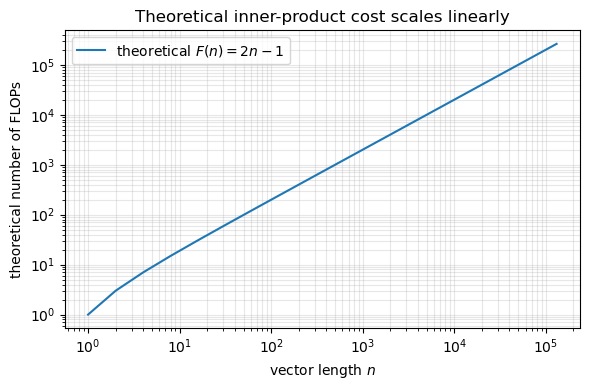

estimated slope of the theoretical curve: 1.028


In [3]:
vector_lengths = 2 ** np.arange(0, 18)
theoretical_flops = 2 * vector_lengths - 1

log_log_slope = np.polyfit(
    np.log(vector_lengths), np.log(theoretical_flops), 1
)[0]

plt.figure(figsize=(6, 4))
plt.loglog(vector_lengths, theoretical_flops, "-",
           label=r"theoretical $F(n)=2n-1$")
plt.xlabel("vector length $n$")
plt.ylabel("theoretical number of FLOPs")
plt.title("Theoretical inner-product cost scales linearly")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("estimated slope of the theoretical curve:",
      round(log_log_slope, 3))

## 3. The effect of a random seed

A pseudorandom-number generator produces a deterministic sequence from its seed. Reusing the same seed reproduces the same sequence; changing the seed produces a different sequence.

The modern NumPy Generator interface creates a local generator and avoids changing random-number generation elsewhere in the notebook.

In [4]:
seed_1 = 2026
seed_2 = 2027

rng_1 = np.random.default_rng(seed_1)
rng_2 = np.random.default_rng(seed_2)

random_vector_1 = rng_1.normal(size=5)
random_vector_2 = rng_2.normal(size=5)

print(f"seed {seed_1}:", np.round(random_vector_1, 4))
print(f"seed {seed_2}:", np.round(random_vector_2, 4))


seed 2026: [-0.7931  0.2406 -1.8963  1.3958  0.6383]
seed 2027: [ 0.1109 -0.0838 -0.8042 -2.1522  1.2119]


In [5]:
rng_1_again = np.random.default_rng(seed_1)
random_vector_1_again = rng_1_again.normal(size=5)

print(f"seed {seed_1}, generated again:",
      np.round(random_vector_1_again, 4))

seed 2026, generated again: [-0.7931  0.2406 -1.8963  1.3958  0.6383]


### What we see

- Different seeds produce different random vectors.
- The same seed reproduces the same random vector.
- Fixing a seed makes a simulation reproducible, but it does not remove randomness from the statistical model.